# Pneumonia em raio-X de tórax com rede convolucional

Classificar radiografias de tórax de pacientes pediátricos em `NORMAL` (0) ou
`PNEUMONIA` (1).

O notebook segue uma linha reta, e as seções são exatamente os passos dela:

**1. pegar as imagens → 2. tratar → 3. separar treino/validação/teste → 4. treinar dois
modelos → 5. comparar os resultados.**

## Por que convolução

A tentativa anterior descreveu a imagem à mão — mediana, Sobel, média ponderada — e jogou o
vetor resultante numa MLP: 77% de acurácia no teste. O gargalo não era a rede, era o descritor. Filtro de borda fixo não sabe o que é
opacidade alveolar.

A convolução inverte quem escolhe o filtro. Em vez de eu decidir que Sobel é o que importa,
a rede começa com kernels aleatórios e o gradiente os empurra para o que reduz a perda. É o
mesmo backpropagation da MLP; o que muda é que os pesos agora são **kernels deslizantes**,
compartilhados por toda a imagem. Duas consequências práticas:

- **Muito menos parâmetros.** Uma camada densa ligando 128×128 pixels a 32 neurônios precisa
  de 524 mil pesos. Trinta e dois kernels 3×3 precisam de 288 — o mesmo detector de borda
  serve para o canto superior esquerdo e para o centro do pulmão.
- **Invariância a translação.** Se a opacidade aparece dois centímetros mais à direita, o
  mesmo kernel dispara, só que noutro ponto do mapa de ativação. A MLP sobre pixels crus
  teria de reaprender o padrão em cada posição.

**Convenção de rótulo:** `0 = NORMAL`, `1 = PNEUMONIA`. A classe positiva é o doente, então
*recall* alto em PNEUMONIA significa "quase não deixa passar doente" — e é essa a métrica que
importa clinicamente, não a acurácia.

> **Como ler as explicações.** Toda decisão do notebook é apresentada na mesma forma:
> **o que é → por que foi escolhido → como impacta o modelo.**

## 0. Ambiente

In [1]:
%matplotlib inline
import os
import time
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score)

SEMENTE = 7
random.seed(SEMENTE)
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)

# MPS = GPU integrada dos Macs Apple Silicon. Cai para CPU em qualquer outra maquina.
DISPOSITIVO = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("torch      ", torch.__version__)
print("dispositivo", DISPOSITIVO)

torch       2.12.1
dispositivo mps


**Semente fixa em todos os geradores.** *Por quê:* `random`, `numpy` e `torch` sorteiam a
inicialização dos pesos, o embaralhamento dos lotes e as perturbações do aumento de dados.
*Impacto:* sem isso, os dois modelos comparados adiante partiriam de inicializações
diferentes, e parte da diferença de acurácia entre eles seria sorte, não arquitetura.

> **Cuidado com MPS:** ele não implementa `float64`. Todo tensor que vai para o dispositivo
> precisa ser `float32` — daí os `.float()` explícitos mais adiante. O `numpy` promove para
> `float64` na primeira divisão descuidada, e o erro aparece longe da linha que o causou.

## 1. Pegar as imagens

Dataset [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia):
radiografias em incidência ântero-posterior de pacientes de 1 a 5 anos do Guangzhou Women and
Children's Medical Center. Cada imagem foi laudada por dois médicos, e o conjunto de teste
passou por um terceiro.

**O dataset completo não está no repositório** (~1,2 GB). O que está versionado é
`imagens_exemplos/` — 8 imagens de `train/` e 8 de `test/`, no mesmo layout do original.
É essa a pasta lida por padrão, então o notebook abre e roda em qualquer máquina até a
seção de pré-processamento. **A partir do treino ele para com erro**: 16 imagens não
formam um lote de 32. Para treinar de verdade, baixe o dataset do Kaggle e defina
`PASTA_RAIOX` antes de abrir o notebook.

> Os resultados e gráficos salvos abaixo vêm de uma execução com o dataset completo, não
> com as imagens de exemplo.

A pasta `val/` original tinha 8 + 8 imagens — pouco demais para escolher
hiperparâmetro — e foi absorvida pelo `train/`; a validação usada aqui é um recorte de 20% do
próprio `train/`.

In [2]:
# Por padrao le as imagens de exemplo versionadas no proprio repositorio
# (case_imagens_raiox/imagens_exemplos), para o notebook rodar em qualquer maquina
# sem depender de caminho local. Sao poucas imagens: servem para inspecionar o
# formato dos dados, nao para treinar.
#
# Para reproduzir os resultados, baixe o dataset completo do Kaggle e aponte:
#     export PASTA_RAIOX="/caminho/para/chest_xray"
PASTA_EXEMPLOS = os.path.join(os.getcwd(), "imagens_exemplos")
PASTA_DADOS = os.environ.get("PASTA_RAIOX", PASTA_EXEMPLOS)

if PASTA_DADOS == PASTA_EXEMPLOS:
    print("usando as imagens de exemplo do repositorio -"
          " defina PASTA_RAIOX para rodar com o dataset completo")
print("dados", PASTA_DADOS)
CLASSES = ["NORMAL", "PNEUMONIA"]   # o indice na lista e o rotulo: NORMAL=0, PNEUMONIA=1
EXTENSOES = (".jpeg", ".jpg", ".png")


def lista_arquivos(particao, classe):
    """Caminhos das imagens de uma classe, ja filtrando .DS_Store e afins."""
    pasta = os.path.join(PASTA_DADOS, particao, classe)
    nomes = sorted(n for n in os.listdir(pasta) if n.lower().endswith(EXTENSOES))
    return [os.path.join(pasta, n) for n in nomes]


inventario = pd.DataFrame(
    [{"particao": p, "classe": c, "imagens": len(lista_arquivos(p, c))}
     for p in ("train", "test") for c in CLASSES]
).pivot(index="particao", columns="classe", values="imagens")

inventario["total"] = inventario.sum(axis=1)
inventario["%_pneumonia"] = (100 * inventario["PNEUMONIA"] / inventario["total"]).round(1)
inventario

classe,NORMAL,PNEUMONIA,total,%_pneumonia
particao,,,,
test,234,390,624,62.5
train,1349,3883,5232,74.2


Duas leituras desta tabela, e as duas voltam no fim do notebook:

1. **O treino é desbalanceado**: 74% pneumonia. Uma rede preguiçosa que responda sempre
   "pneumonia" já acerta 74% no treino — e a perda cai, dando a impressão de que está
   aprendendo. *Impacto no modelo:* a rede absorve esse viés a priori e empurra as
   probabilidades para cima; é o que justifica a seção 6 (ajuste do limiar).
2. **O teste é desbalanceado de forma diferente**: 62,5%. As duas pastas não são amostras da
   mesma população — o `test/` foi curado à parte. *Impacto:* o número que vale é sempre o do
   `test/`, e a **linha de base a bater é 62,5%**, não 50%.

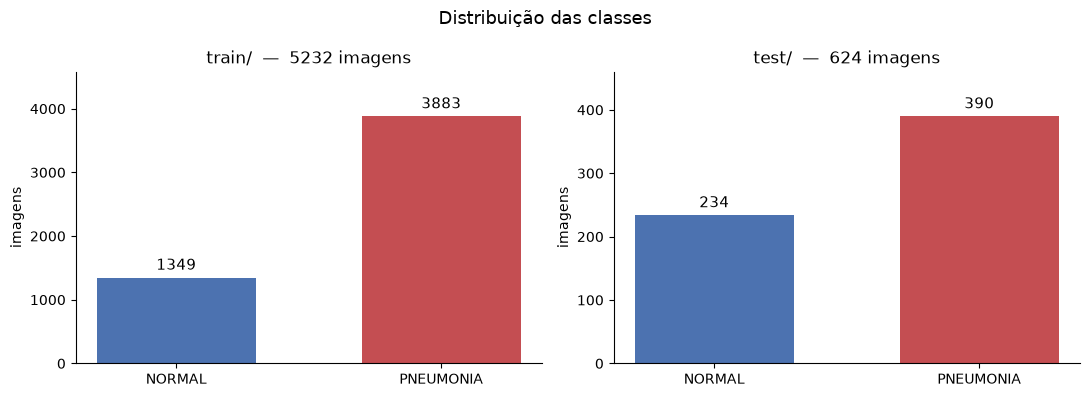

In [3]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

for eixo, particao in zip(eixos, ("train", "test")):
    alturas = [inventario.loc[particao, c] for c in CLASSES]
    barras = eixo.bar(CLASSES, alturas, color=["#4C72B0", "#C44E52"], width=0.6)
    eixo.bar_label(barras, padding=3, fontsize=11)
    eixo.set_title(f"{particao}/  —  {inventario.loc[particao, 'total']} imagens")
    eixo.set_ylabel("imagens")
    eixo.set_ylim(0, max(alturas) * 1.18)
    eixo.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribuição das classes", fontsize=13)
fig.tight_layout()
plt.show()

**Como são as imagens.** Quatro de cada classe, direto do disco, sem nenhum tratamento:

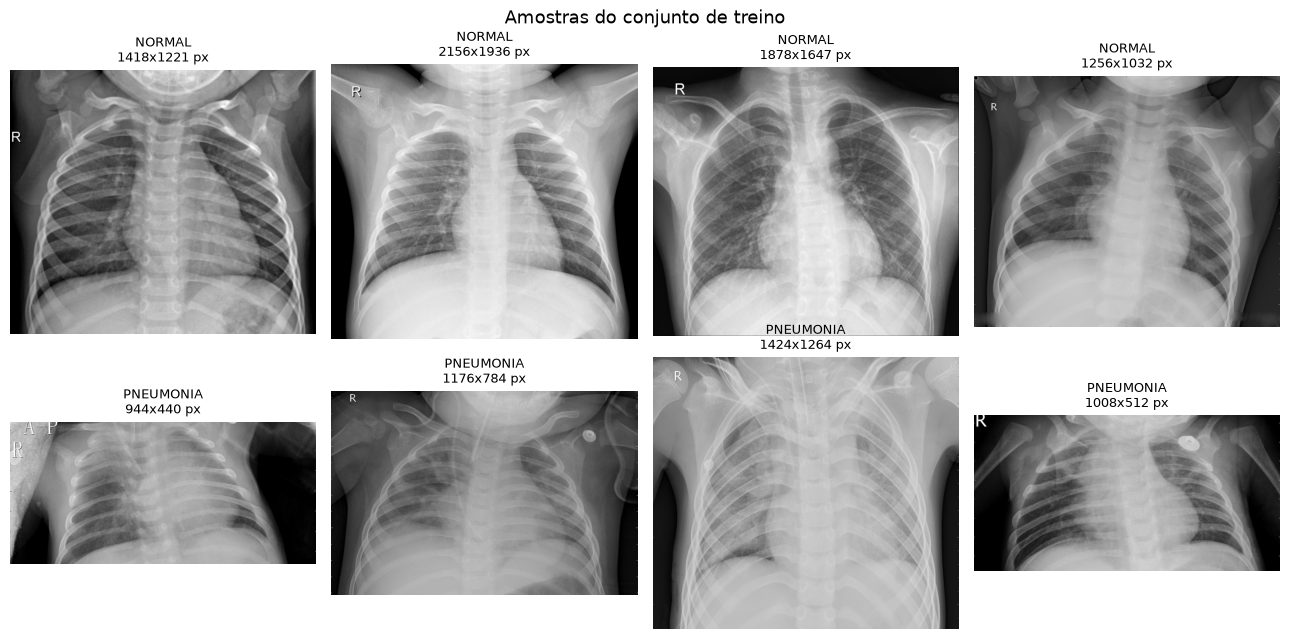

In [4]:
fig, eixos = plt.subplots(2, 4, figsize=(13, 6.5))

for linha, classe in enumerate(CLASSES):
    caminhos = lista_arquivos("train", classe)
    sorteio = random.Random(SEMENTE).sample(caminhos, 4)
    for coluna, caminho in enumerate(sorteio):
        imagem = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
        eixo = eixos[linha, coluna]
        eixo.imshow(imagem, cmap="gray")
        eixo.set_title(f"{classe}\n{imagem.shape[1]}x{imagem.shape[0]} px", fontsize=9)
        eixo.axis("off")

fig.suptitle("Amostras do conjunto de treino", fontsize=13)
fig.tight_layout()
plt.show()

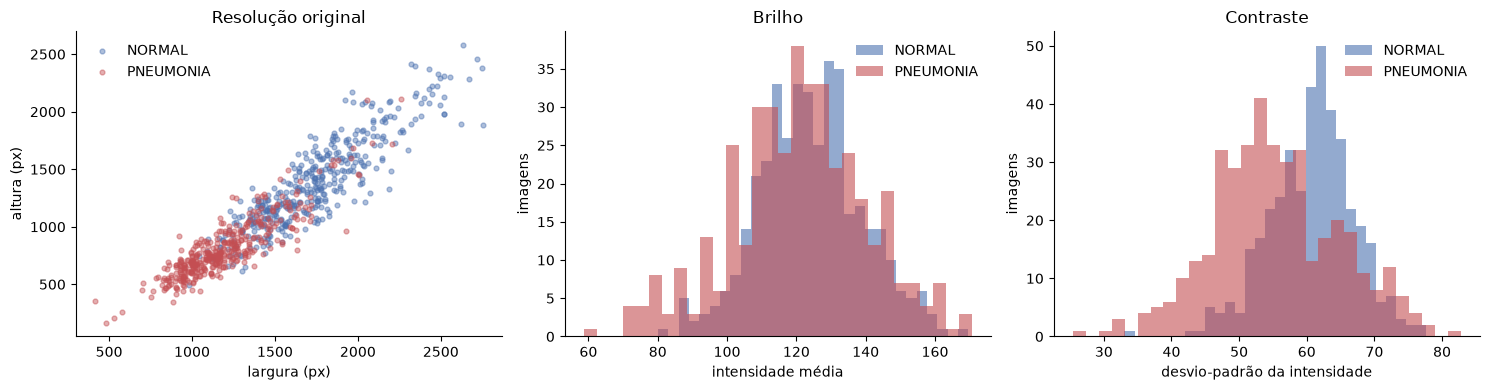

In [5]:
# Dimensoes e brilho: uma amostra de 200 por classe basta para ver a dispersao.
registros = []
for particao in ("train", "test"):
    for classe in CLASSES:
        caminhos = lista_arquivos(particao, classe)
        for caminho in random.Random(SEMENTE).sample(caminhos, min(200, len(caminhos))):
            imagem = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
            registros.append({
                "particao": particao, "classe": classe,
                "largura": imagem.shape[1], "altura": imagem.shape[0],
                "brilho": imagem.mean(), "contraste": imagem.std(),
            })

amostra = pd.DataFrame(registros)

fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
cores = {"NORMAL": "#4C72B0", "PNEUMONIA": "#C44E52"}

for classe in CLASSES:
    recorte = amostra[amostra.classe == classe]
    eixos[0].scatter(recorte.largura, recorte.altura, s=12, alpha=0.45,
                     label=classe, color=cores[classe])
    eixos[1].hist(recorte.brilho, bins=30, alpha=0.6, label=classe, color=cores[classe])
    eixos[2].hist(recorte.contraste, bins=30, alpha=0.6, label=classe, color=cores[classe])

eixos[0].set(xlabel="largura (px)", ylabel="altura (px)", title="Resolução original")
eixos[1].set(xlabel="intensidade média", ylabel="imagens", title="Brilho")
eixos[2].set(xlabel="desvio-padrão da intensidade", ylabel="imagens", title="Contraste")

for eixo in eixos:
    eixo.legend(frameon=False)
    eixo.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

A olho nu a diferença clínica existe, mas é sutil: nas pneumonias o campo pulmonar aparece
mais esbranquiçado e com contornos borrados nas bases — é o infiltrado. Nas normais o pulmão
é escuro e uniforme, e dá para seguir a trama vascular.

Os três painéis mostram os **dois problemas que o tratamento da seção 2 tem de resolver**:

- **Enquadramento** (painel da esquerda): a resolução vai de poucas centenas a mais de 2000 px
  e a proporção largura/altura não é constante. A rede exige lotes de tamanho fixo — logo,
  alguém tem de padronizar isso.
- **Aquisição** (painéis do meio e da direita): brilho e contraste se espalham por uma faixa
  larga **dentro de cada classe**. Parte dessa variação é aparelho e exposição, não patologia.
  *Impacto no modelo:* é exatamente o tipo de sinal espúrio que a rede pode aprender no lugar
  do achado clínico — e que faz o desempenho despencar quando ela encontra um aparelho
  diferente, como acontece entre `train/` e `test/`.

## 2. Tratar as imagens

Quatro operações, nesta ordem. Cada uma responde a um problema visto acima.

### 2.1 Redimensionar para 128×128, tons de cinza

*O que é:* toda imagem vira uma matriz 128×128 de um canal, com `cv2.INTER_AREA`.

*Por que foi escolhido:* a rede precisa de entrada de tamanho fixo, e 128×128 é o maior lado
que mantém as 5232 imagens de treino inteiras na memória desta máquina (86 MB em `uint8`).
`INTER_AREA` é o reamostrador correto para **reduzir**: ele faz a média dos pixels que
colapsam, em vez de sortear um deles como o `INTER_LINEAR`. Raio-X é grayscale por natureza —
manter três canais idênticos triplicaria o custo da primeira convolução sem acrescentar
informação.

*Como impacta o modelo:* o infiltrado é um achado de textura em escala de centímetros, que
sobrevive a 128×128; o que se perde é detalhe fino, que não é o sinal procurado. Reduzir com
o interpolador errado introduz *aliasing* — padrão de alta frequência que não existe no
paciente e que os primeiros kernels aprenderiam com prazer.

### 2.2 Dividir por 255

*O que é:* levar o pixel de `[0, 255]` para `[0, 1]`, em `float32`, **por lote**.

*Por que foi escolhido:* é a normalização mais barata possível e, ao contrário de padronizar
por pixel (subtrair a média do conjunto), não usa estatística nenhuma calculada sobre os
dados — logo, não há como vazar informação do teste para o treino. A conversão acontece dentro
do laço de treino porque promover a matriz inteira para `float32` de uma vez é o que travava o
notebook da MLP.

*Como impacta o modelo:* mantém ativações e gradientes numa escala em que o passo de 1e-3 do
RMSprop é razoável. Com entrada em `[0, 255]`, os primeiros gradientes ficam duas ordens de
grandeza maiores e o treino diverge ou estagna.

### 2.3 CLAHE — equalização de contraste local

*O que é:* *Contrast Limited Adaptive Histogram Equalization*. Equaliza o histograma em blocos
de 8×8, não na imagem toda: cada região ganha o próprio ajuste, o que traz à tona textura em
áreas escuras sem estourar as claras. O "contrast limited" (`clipLimit=2.0`) é o corte que
impede o ruído de fundo de virar granulado — acima de ~4 o granulado aparece.

*Por que foi escolhido:* é normalização **por imagem**, e ataca diretamente a dispersão de
brilho/contraste do painel anterior. Duas radiografias tiradas com exposições diferentes ficam
parecidas depois do CLAHE.

*Como impacta o modelo:* remove da entrada uma variável que correlaciona com a pasta de origem
mas não com a doença. Sem isso, a rede tem um atalho disponível — decidir pelo nível de
exposição — que funciona na validação (mesma origem do treino) e falha no `test/`, que foi
adquirido à parte. É a explicação mais provável para o abismo entre 3% de erro na validação e
23% no teste que a versão anterior deste trabalho registrou.

### 2.4 Aumento de dados (só no treino)

*O que é:* a cada época, uma transformação aleatória diferente sobre a mesma imagem — rotação,
zoom, deslocamento e espelhamento horizontal, tudo numa única matriz afim.

*Por que foi escolhido:* 4185 imagens de treino é pouco para uma rede com ~900 mil parâmetros;
sem aumento ela tem capacidade de decorar o conjunto. Os parâmetros aqui são **mais contidos
que o costume** (±18° em vez de ±30°, zoom de 15% em vez de 20%): raio-X de tórax é um exame
enquadrado de forma padronizada — paciente de pé, centralizado —, e a inclinação real entre
dois exames é pequena. Rotação de 30° gera imagem que não existe na clínica, e ensinar a rede a
ser invariante a ela é gastar capacidade com nada. O espelhamento é o único generoso, e é
discutível (inverte a posição do coração), mas dobra os exemplos e a rede não usa lateralidade
para decidir opacidade.

*Como impacta o modelo:* a rede nunca vê duas vezes o mesmo pixel na mesma posição, o que
fecha a distância entre a curva de treino e a de validação. Efeito colateral que aparece nos
gráficos da seção 5: a acurácia de **treino** fica mais baixa que a de validação, porque o
treino é medido sobre imagens perturbadas, que são mais difíceis que as originais.

> **O aumento vale só para o treino.** Validação e teste passam pelo CLAHE (determinístico) e
> por mais nada. Avaliar sobre imagem perturbada mede a rede contra um alvo que muda a cada
> execução — ruído disfarçado de resultado.

In [6]:
LADO = 128


def carrega_particao(particao):
    """Le uma particao inteira para um array uint8 (N, LADO, LADO) e os rotulos."""
    pixels, rotulos = [], []
    for rotulo, classe in enumerate(CLASSES):
        for caminho in lista_arquivos(particao, classe):
            imagem = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
            if imagem is None:          # arquivo corrompido: pula em vez de quebrar
                continue
            pixels.append(cv2.resize(imagem, (LADO, LADO), interpolation=cv2.INTER_AREA))
            rotulos.append(rotulo)
    return np.stack(pixels), np.array(rotulos, dtype=np.float32)


relogio = time.time()
pixels_completo, rotulos_completo = carrega_particao("train")
pixels_teste, rotulos_teste = carrega_particao("test")

print(f"carga concluida em {time.time() - relogio:.0f}s")
print(f"train  {pixels_completo.shape}  {pixels_completo.nbytes / 1e6:.0f} MB")
print(f"test   {pixels_teste.shape}  {pixels_teste.nbytes / 1e6:.0f} MB")

carga concluida em 57s
train  (5232, 128, 128)  86 MB
test   (624, 128, 128)  10 MB


In [7]:
EQUALIZADOR = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

GRAUS_MAX = 18.0      # rotacao, em graus, para cada lado
ZOOM_MAX = 0.15       # fator de escala: sorteado em [1 - ZOOM_MAX, 1 + ZOOM_MAX]
DESLOCA_MAX = 0.08    # translacao, como fracao do lado
PROB_ESPELHO = 0.5


def realca(imagem):
    """CLAHE: normalizacao por imagem, equaliza o contraste local."""
    return EQUALIZADOR.apply(imagem)


def perturba(imagem, sorteador):
    """Rotacao + zoom + deslocamento numa unica matriz afim, mais espelho opcional."""
    angulo = sorteador.uniform(-GRAUS_MAX, GRAUS_MAX)
    escala = sorteador.uniform(1 - ZOOM_MAX, 1 + ZOOM_MAX)
    centro = (LADO / 2 - 0.5, LADO / 2 - 0.5)

    matriz = cv2.getRotationMatrix2D(centro, angulo, escala)
    matriz[0, 2] += sorteador.uniform(-DESLOCA_MAX, DESLOCA_MAX) * LADO
    matriz[1, 2] += sorteador.uniform(-DESLOCA_MAX, DESLOCA_MAX) * LADO

    # BORDER_REFLECT_101 espelha a borda em vez de preencher com preto: evita ensinar
    # a rede que "faixa preta reta na lateral" e um atributo com significado.
    saida = cv2.warpAffine(imagem, matriz, (LADO, LADO),
                           flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    if sorteador.random() < PROB_ESPELHO:
        saida = cv2.flip(saida, 1)
    return saida

O que cada etapa faz com a mesma radiografia:

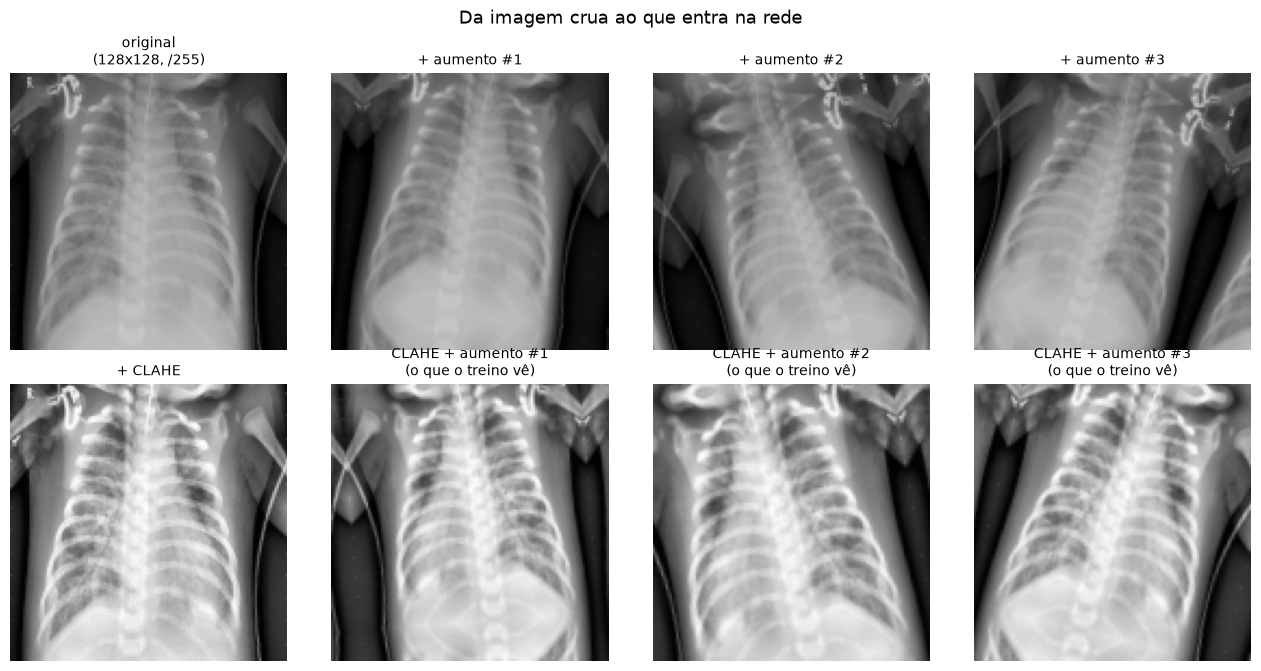

In [8]:
exemplo = pixels_completo[int(np.argmax(rotulos_completo))]   # uma pneumonia qualquer
sorteador_demo = random.Random(SEMENTE)

fig, eixos = plt.subplots(2, 4, figsize=(13, 6.8))

eixos[0, 0].imshow(exemplo, cmap="gray", vmin=0, vmax=255)
eixos[0, 0].set_title("original\n(128x128, /255)", fontsize=10)

eixos[1, 0].imshow(realca(exemplo), cmap="gray", vmin=0, vmax=255)
eixos[1, 0].set_title("+ CLAHE", fontsize=10)

for coluna in range(1, 4):
    eixos[0, coluna].imshow(perturba(exemplo, sorteador_demo),
                            cmap="gray", vmin=0, vmax=255)
    eixos[0, coluna].set_title(f"+ aumento #{coluna}", fontsize=10)

    eixos[1, coluna].imshow(perturba(realca(exemplo), sorteador_demo),
                            cmap="gray", vmin=0, vmax=255)
    eixos[1, coluna].set_title(f"CLAHE + aumento #{coluna}\n(o que o treino vê)", fontsize=10)

for eixo in eixos.ravel():
    eixo.axis("off")

fig.suptitle("Da imagem crua ao que entra na rede", fontsize=13)
fig.tight_layout()
plt.show()

Na linha de baixo o CLAHE deixa a trama pulmonar visivelmente mais destacada e o fundo menos
"lavado". Nas colunas 2 a 4, cada passagem gera um enquadramento diferente — é o que a rede vê
a cada época. A célula inferior direita é literalmente a entrada de treino; a inferior
esquerda é a de validação e teste.

## 3. Separar treino, validação e teste

*O que é:* `train/` é cortado em 80% treino e 20% validação, de forma **estratificada**; o
`test/` inteiro fica intocado até a seção 5.

*Por que foi escolhido:* são três papéis distintos e incompatíveis. O treino ajusta pesos; a
validação escolhe o que não é peso (qual modelo vence, qual limiar usar, quando o passo cai);
o teste dá a única estimativa não contaminada de desempenho. Estratificar mantém a proporção
74/26 nas duas metades — sem isso, um recorte com proporção diferente muda o viés a priori
entre treino e validação e a comparação deixa de significar algo.

*Como impacta o modelo:* qualquer decisão tomada olhando o teste vaza para o número final e o
deixa otimista por construção. Foi um dos consertos do notebook da MLP: lá, média, desvio e PCA
eram ajustados sobre a matriz inteira e só depois a validação era separada. Aqui a divisão vem
**antes** de qualquer estatística derivada dos dados — o risco é pequeno (a única normalização
é dividir por 255, uma constante, e o CLAHE olha uma imagem por vez), mas a ordem correta não
custa nada e vale como hábito.

In [9]:
pixels_treino, pixels_val, rotulos_treino, rotulos_val = train_test_split(
    pixels_completo, rotulos_completo,
    test_size=0.20, stratify=rotulos_completo, random_state=SEMENTE,
)

divisao = pd.DataFrame({
    "conjunto": ["treino", "validação", "teste"],
    "imagens": [len(rotulos_treino), len(rotulos_val), len(rotulos_teste)],
    "% pneumonia": [round(100 * float(r.mean()), 1)
                    for r in (rotulos_treino, rotulos_val, rotulos_teste)],
    "origem": ["80% de train/", "20% de train/", "test/ inteiro"],
    "serve para": ["ajustar os pesos", "escolher modelo e limiar", "estimativa final"],
})
divisao

,conjunto,imagens,% pneumonia,origem,serve para
0,treino,4185,74.2,80% de train/,ajustar os pesos
1,validação,1047,74.2,20% de train/,escolher modelo e limiar
2,teste,624,62.5,test/ inteiro,estimativa final


O `Dataset` abaixo é onde o tratamento da seção 2 encontra a divisão: ele recebe a matriz
`uint8` já redimensionada e aplica, por imagem, o CLAHE (sempre) e a perturbação (só quando
`aumenta=True`, isto é, só no treino).

In [10]:
class ConjuntoRaioX(Dataset):
    """Entrega tensores (1, LADO, LADO) em float32, com o tratamento configurado."""

    def __init__(self, pixels, rotulos, aumenta, semente=SEMENTE):
        self.pixels = pixels
        self.rotulos = rotulos
        self.aumenta = aumenta
        self.sorteador = random.Random(semente)

    def __len__(self):
        return len(self.rotulos)

    def __getitem__(self, indice):
        imagem = realca(self.pixels[indice])          # CLAHE: treino, validacao e teste
        if self.aumenta:                              # perturbacao: so no treino
            imagem = perturba(imagem, self.sorteador)
        tensor = torch.from_numpy(np.ascontiguousarray(imagem)).float().div_(255.0)
        return tensor.unsqueeze(0), torch.tensor(self.rotulos[indice])

## 4. Os dois modelos

Os dois recebem **exatamente a mesma entrada** — mesmo CLAHE, mesmo aumento, mesma divisão,
mesma semente. A única coisa que muda é a arquitetura, e é isso que torna a comparação
interpretável: se um vencer, foi a arquitetura, não o pré-processamento.

### Modelo 1 — CNN simples (a referência mínima)

```
[Conv 3x3 -> ReLU -> MaxPool 2x2] x 3     ->  Flatten  ->  Linear(64)  ->  Linear(1)
canais: 1 -> 16 -> 32 -> 64                   128 -> 64 -> 32 -> 16
```

*Por que este modelo foi escolhido:* é a CNN mais crua que ainda é uma CNN — convolução,
não-linearidade e sub-amostragem, sem nenhum truque de regularização ou estabilização. Ele
existe para responder "quanto do resultado vem só de trocar o descritor artesanal por kernels
aprendidos?". Sem esse piso, não há como saber se `BatchNorm` e `Dropout` do modelo 2 estão
comprando alguma coisa ou só encompridando o código.

*Como a arquitetura impacta o resultado:* três blocos param em 16×16, então o vetor achatado
tem 64×16×16 = 16.384 posições. A camada densa que vem depois custa **mais de um milhão de
pesos** — a maior parte do modelo está num lugar que não é convolucional e é justamente onde
mais se decora. Sem `BatchNorm`, a escala das ativações depende da inicialização; sem
`Dropout`, nada impede a densa de memorizar.

### Modelo 2 — CNN profunda com BatchNorm e Dropout

```
[Conv 3x3 -> BatchNorm -> ReLU -> (Dropout) -> MaxPool 2x2] x 5  ->  Flatten -> Linear(128) -> Dropout -> Linear(1)
canais: 1 -> 32 -> 64 -> 64 -> 128 -> 256                            128 -> 64 -> 32 -> 16 -> 8 -> 4
```

*Por que este modelo foi escolhido:* é a arquitetura padrão para classificação binária de
imagem média-resolução treinada do zero, e cada peça responde a uma limitação concreta do
modelo 1:

- **`padding="same"`** mantém o tamanho na convolução, para que só o `MaxPool` reduza. Assim a
  conta de dimensões é uma divisão por 2 por bloco: 128 → 64 → 32 → 16 → 8 → 4. *Impacto:*
  sem padding, cinco blocos comeriam a borda da imagem — onde ficam as bases pulmonares.
- **`BatchNorm` antes da ReLU** renormaliza as ativações a cada lote. *Impacto:* mantém o
  gradiente numa escala utilizável através das cinco camadas e permite passo maior; sem ela,
  uma rede desta profundidade treinada do zero com RMSprop costuma estagnar.
- **`Dropout` só nos blocos profundos** (0,1 no segundo, 0,2 do quarto em diante). *Por quê:*
  as primeiras camadas aprendem borda e textura, coisas genéricas que não decoram exemplo; o
  excesso de ajuste mora nas camadas de cima. *Impacto:* desligar unidades cedo demais
  atrapalha o aprendizado das bordas sem reduzir a memorização.
- **Canais dobrando** (32 → 64 → 64 → 128 → 256) enquanto a resolução cai pela metade.
  *Impacto:* perde-se detalhe espacial e ganha-se número de padrões distintos detectáveis — e
  o volume final 256×4×4 achata para 4096, quatro vezes menor que o do modelo 1, o que **reduz**
  a camada densa apesar de a rede ser mais profunda.

> **Tudo acima é hipótese, não resultado.** É o raciocínio de projeto que justifica *construir* o
> modelo 2 desta forma, e é um raciocínio correto. Se ele se confirma neste dataset é outra
> pergunta — quem responde é a seção 6, e a resposta não é a esperada. O ponto do notebook está
> tanto no argumento quanto no que o experimento faz com ele.

### Saída em logit, não em probabilidade

Os dois terminam numa camada linear de **um neurônio**, sem `sigmoid`, e a perda é
`BCEWithLogitsLoss`. *Por quê:* essa perda aplica o sigmoide internamente com o truque do
*log-sum-exp*. *Impacto:* logit muito negativo com `sigmoid` explícito vira `0.0` exato em
`float32`, e o `log(0)` seguinte produz `inf` — o treino morre sem mensagem clara. Para
interpretar a saída como probabilidade, basta aplicar `torch.sigmoid` na hora de avaliar.

In [11]:
def bloco_simples(entradas, saidas):
    """Conv -> ReLU -> MaxPool: o bloco convolucional sem nenhum acessorio."""
    return [
        nn.Conv2d(entradas, saidas, kernel_size=3, padding="same"),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    ]


def bloco_regularizado(entradas, saidas, dropout=0.0):
    """Conv -> BatchNorm -> ReLU -> [Dropout] -> MaxPool."""
    camadas = [
        nn.Conv2d(entradas, saidas, kernel_size=3, padding="same", bias=False),
        nn.BatchNorm2d(saidas),
        nn.ReLU(inplace=True),
    ]
    if dropout:
        camadas.append(nn.Dropout(dropout))
    camadas.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return camadas


def modelo_simples():
    """Modelo 1: tres blocos, sem BatchNorm e sem Dropout."""
    lado_final = LADO // 2 ** 3          # 128 -> 16
    return nn.Sequential(
        *bloco_simples(1, 16),
        *bloco_simples(16, 32),
        *bloco_simples(32, 64),
        nn.Flatten(),
        nn.Linear(64 * lado_final * lado_final, 64),
        nn.ReLU(inplace=True),
        nn.Linear(64, 1),
    )


def modelo_profundo():
    """Modelo 2: cinco blocos, BatchNorm em todos e Dropout nos profundos."""
    lado_final = LADO // 2 ** 5          # 128 -> 4
    return nn.Sequential(
        *bloco_regularizado(1, 32),
        *bloco_regularizado(32, 64, dropout=0.1),
        *bloco_regularizado(64, 64),
        *bloco_regularizado(64, 128, dropout=0.2),
        *bloco_regularizado(128, 256, dropout=0.2),
        nn.Flatten(),
        nn.Linear(256 * lado_final * lado_final, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
    )


MODELOS = {
    "1 — CNN simples":   modelo_simples,
    "2 — CNN profunda":  modelo_profundo,
}

In [12]:
def descreve(rede):
    """Equivalente caseiro do summary: passa um lote falso e anota as formas."""
    linhas, volume = [], torch.zeros(1, 1, LADO, LADO)
    rede_cpu = rede.to("cpu").eval()
    with torch.no_grad():
        for camada in rede_cpu:
            volume = camada(volume)
            linhas.append({
                "camada": type(camada).__name__,
                "saída": "x".join(str(d) for d in tuple(volume.shape)[1:]),
                "parâmetros": sum(p.numel() for p in camada.parameters()),
            })
    return pd.DataFrame(linhas)


for nome, construtor in MODELOS.items():
    resumo = descreve(construtor())
    convolucional = resumo[resumo.camada == "Conv2d"]["parâmetros"].sum()
    denso = resumo[resumo.camada == "Linear"]["parâmetros"].sum()
    print(f"{nome:20s}  total {resumo['parâmetros'].sum():>9,}  "
          f"| convolucoes {convolucional:>8,}  | densas {denso:>9,}")

descreve(modelo_profundo())

1 — CNN simples       total 1,072,001  | convolucoes   23,296  | densas 1,048,705
2 — CNN profunda      total   949,857  | convolucoes  424,224  | densas   524,545


,camada,saída,parâmetros
0,Conv2d,32x128x128,288
1,BatchNorm2d,32x128x128,64
2,ReLU,32x128x128,0
3,MaxPool2d,32x64x64,0
4,Conv2d,64x64x64,18432
5,BatchNorm2d,64x64x64,128
6,ReLU,64x64x64,0
7,Dropout,64x64x64,0
8,MaxPool2d,64x32x32,0
9,Conv2d,64x32x32,36864


A tabela impressa acima é o argumento central da seção: **o modelo "simples" tem mais
parâmetros que o profundo**, e quase todos numa única camada densa. Profundidade aqui não
significa modelo maior — significa capacidade deslocada da memorização (densa) para a detecção
de padrões (convolução). É essa troca que a comparação de resultados vai medir.

## 5. Treinar

Mesmo protocolo para os dois modelos: **RMSprop**, passo inicial 1e-3, lotes de 32, 12 épocas.
O passo cai por um fator de 0,3 sempre que a acurácia de validação passa 2 épocas sem melhorar
(`ReduceLROnPlateau` em modo `max`) — quando o treino começa a oscilar em torno de um mínimo,
encurtar o passo rende mais que insistir.

*Por que o mesmo protocolo:* dar ao modelo 2 um otimizador melhor tornaria impossível atribuir
a diferença à arquitetura.

Três decisões menores que valem registro:

- **`torch.manual_seed(SEMENTE)` dentro de `treina`, duas vezes.** A primeira chamada, antes de
  construir a rede, dá aos dois modelos a mesma sequência de inicialização. A segunda, logo
  depois de construída, é necessária porque redes de tamanhos diferentes consomem quantidades
  diferentes do gerador ao serem inicializadas — sem ela, o embaralhamento dos lotes sairia
  diferente nos dois treinos. *Impacto:* os dois modelos veem os mesmos lotes, na mesma ordem,
  com as mesmas perturbações; a diferença de resultado só pode vir da arquitetura.
- **`num_workers=0`.** Carregar em processos paralelos no macOS usa `fork`, que não se dá bem
  com o contexto do Metal. O ganho seria pequeno: perturbar uma imagem 128×128 no OpenCV custa
  dezenas de microssegundos, contra dezenas de milissegundos da passagem pela rede.
- **`drop_last=True` no treino.** O `BatchNorm` calcula média e desvio dentro do lote; um lote
  final com 2 ou 3 imagens dá estatística instável e injeta ruído no fim de cada época.

In [13]:
EPOCAS = 12
TAMANHO_LOTE = 32
PASSO_INICIAL = 1e-3


def avalia(rede, carregador):
    """Perda media, acuracia e probabilidades previstas, sem atualizar pesos."""
    rede.eval()
    criterio = nn.BCEWithLogitsLoss(reduction="sum")
    perda_total, acertos, probabilidades = 0.0, 0, []

    with torch.no_grad():
        for lote, alvos in carregador:
            lote, alvos = lote.to(DISPOSITIVO), alvos.to(DISPOSITIVO)
            logits = rede(lote).squeeze(1)
            perda_total += criterio(logits, alvos).item()
            proba = torch.sigmoid(logits)
            acertos += ((proba >= 0.5).float() == alvos).sum().item()
            probabilidades.append(proba.cpu())

    n = len(carregador.dataset)
    return perda_total / n, acertos / n, torch.cat(probabilidades).numpy()


def probabilidades_de(rede, pixels, rotulos):
    dados = ConjuntoRaioX(pixels, rotulos, aumenta=False)
    carregador = DataLoader(dados, batch_size=64, shuffle=False, num_workers=0)
    return avalia(rede, carregador)[2]


def treina(construtor, verbose=True):
    """Treina um modelo do zero e devolve a rede e o historico por epoca."""
    torch.manual_seed(SEMENTE)          # mesma inicializacao nos dois modelos

    dados_treino = ConjuntoRaioX(pixels_treino, rotulos_treino, aumenta=True)
    dados_val = ConjuntoRaioX(pixels_val, rotulos_val, aumenta=False)

    carregador_treino = DataLoader(dados_treino, batch_size=TAMANHO_LOTE, shuffle=True,
                                   num_workers=0, drop_last=True)
    carregador_val = DataLoader(dados_val, batch_size=64, shuffle=False, num_workers=0)

    rede = construtor().to(DISPOSITIVO)
    torch.manual_seed(SEMENTE)          # redes de tamanhos diferentes consomem quantidades
                                        # diferentes do gerador; resemear aqui garante que o
                                        # embaralhamento dos lotes tambem seja identico
    otimizador = torch.optim.RMSprop(rede.parameters(), lr=PASSO_INICIAL)
    agendador = torch.optim.lr_scheduler.ReduceLROnPlateau(
        otimizador, mode="max", factor=0.3, patience=2, min_lr=1e-6)
    criterio = nn.BCEWithLogitsLoss()

    historico = {"perda": [], "acuracia": [], "perda_val": [],
                 "acuracia_val": [], "passo": []}
    relogio = time.time()

    for epoca in range(1, EPOCAS + 1):
        rede.train()
        soma_perda, acertos, vistos = 0.0, 0, 0

        for lote, alvos in carregador_treino:
            lote, alvos = lote.to(DISPOSITIVO), alvos.to(DISPOSITIVO)
            otimizador.zero_grad(set_to_none=True)
            logits = rede(lote).squeeze(1)
            perda = criterio(logits, alvos)
            perda.backward()
            otimizador.step()

            soma_perda += perda.item() * len(alvos)
            acertos += ((torch.sigmoid(logits) >= 0.5).float() == alvos).sum().item()
            vistos += len(alvos)

        perda_val, acuracia_val, _ = avalia(rede, carregador_val)
        passo_atual = otimizador.param_groups[0]["lr"]
        agendador.step(acuracia_val)

        historico["perda"].append(soma_perda / vistos)
        historico["acuracia"].append(acertos / vistos)
        historico["perda_val"].append(perda_val)
        historico["acuracia_val"].append(acuracia_val)
        historico["passo"].append(passo_atual)

        if verbose:
            print(f"  época {epoca:2d}/{EPOCAS}  "
                  f"perda {soma_perda / vistos:.4f}  acc {acertos / vistos:.4f}  |  "
                  f"val perda {perda_val:.4f}  val acc {acuracia_val:.4f}  "
                  f"| passo {passo_atual:.1e}")

    if verbose:
        print(f"  concluído em {time.time() - relogio:.0f}s")
    return rede, historico

In [14]:
redes, historicos = {}, {}

for nome, construtor in MODELOS.items():
    print(f"\n{nome}")
    rede, historico = treina(construtor)
    redes[nome] = rede
    historicos[nome] = historico


1 — CNN simples


  época  1/12  perda 0.4722  acc 0.8005  |  val perda 0.2535  val acc 0.9064  | passo 1.0e-03


  época  2/12  perda 0.2634  acc 0.8877  |  val perda 0.1859  val acc 0.9370  | passo 1.0e-03


  época  3/12  perda 0.2326  acc 0.9058  |  val perda 0.1612  val acc 0.9446  | passo 1.0e-03


  época  4/12  perda 0.2131  acc 0.9207  |  val perda 0.1445  val acc 0.9436  | passo 1.0e-03


...

  época  8/12  perda 0.1296  acc 0.9560  |  val perda 0.1525  val acc 0.9351  | passo 1.0e-03


  época  9/12  perda 0.1391  acc 0.9548  |  val perda 0.2169  val acc 0.8968  | passo 1.0e-03


  época 10/12  perda 0.0992  acc 0.9632  |  val perda 0.1324  val acc 0.9408  | passo 3.0e-04


  época 11/12  perda 0.0934  acc 0.9647  |  val perda 0.1691  val acc 0.9293  | passo 3.0e-04


  época 12/12  perda 0.0961  acc 0.9683  |  val perda 0.1749  val acc 0.9245  | passo 3.0e-04
  concluído em 151s


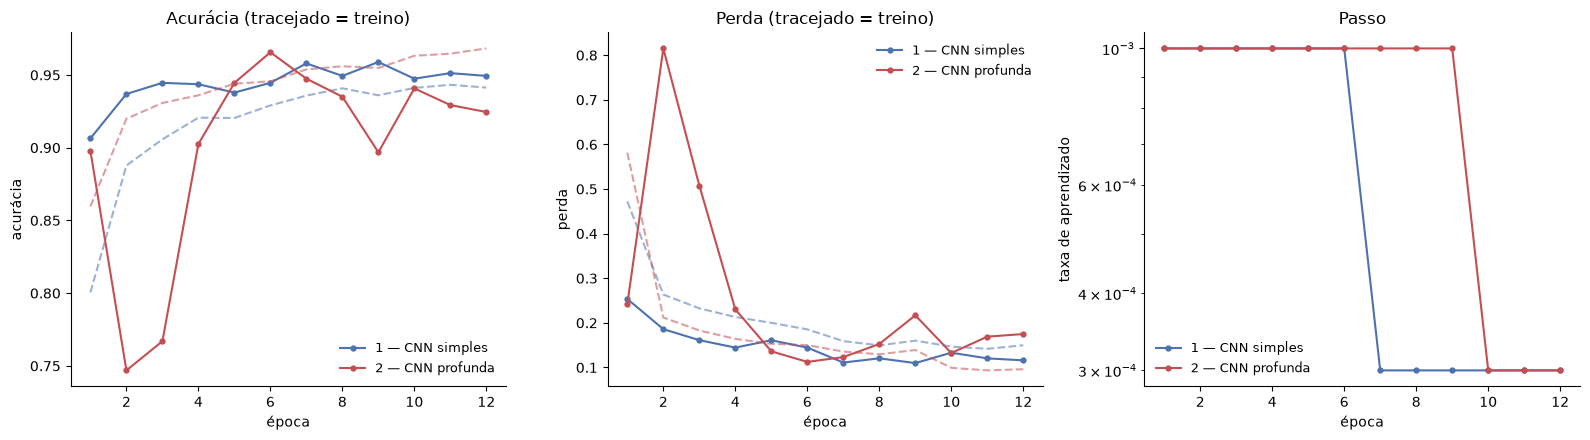

In [15]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
paleta = {"1 — CNN simples": "#4C72B0", "2 — CNN profunda": "#C44E52"}
epocas = range(1, EPOCAS + 1)

for nome, historico in historicos.items():
    eixos[0].plot(epocas, historico["acuracia"], "--", color=paleta[nome], alpha=0.55)
    eixos[0].plot(epocas, historico["acuracia_val"], "-o", ms=3.5,
                  color=paleta[nome], label=nome)
    eixos[1].plot(epocas, historico["perda"], "--", color=paleta[nome], alpha=0.55)
    eixos[1].plot(epocas, historico["perda_val"], "-o", ms=3.5,
                  color=paleta[nome], label=nome)
    eixos[2].plot(epocas, historico["passo"], "-o", ms=3.5,
                  color=paleta[nome], label=nome)

eixos[0].set(xlabel="época", ylabel="acurácia", title="Acurácia (tracejado = treino)")
eixos[1].set(xlabel="época", ylabel="perda", title="Perda (tracejado = treino)")
eixos[2].set(xlabel="época", ylabel="taxa de aprendizado", title="Passo", yscale="log")

for eixo in eixos:
    eixo.legend(frameon=False, fontsize=9)
    eixo.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

A distância entre a linha tracejada (treino) e a cheia (validação) é a leitura de excesso de
ajuste. Como o aumento de dados está ligado nos dois, a curva de treino é medida sobre imagens
perturbadas — mais difíceis que as originais que a validação vê —, então ela ficar *abaixo* da
validação é o comportamento esperado, não um erro. O painel do passo mostra onde o
`ReduceLROnPlateau` interveio: cada degrau é uma estagnação de 2 épocas na acurácia de
validação.

## 6. Resultados

Só agora o `test/` entra. As 624 imagens não participaram de nenhuma decisão até aqui — nem de
peso, nem de arquitetura, nem de escolha de modelo. Elas passam pelo CLAHE determinístico e por
mais nada.

In [16]:
def mede_no_teste(nome, rede, limiar=0.5):
    dados = ConjuntoRaioX(pixels_teste, rotulos_teste, aumenta=False)
    carregador = DataLoader(dados, batch_size=64, shuffle=False, num_workers=0)
    perda, _, probabilidades = avalia(rede, carregador)

    previsoes = (probabilidades >= limiar).astype(np.float32)
    (vn, fp), (fn, vp) = confusion_matrix(rotulos_teste, previsoes)

    return {
        "modelo": nome,
        "perda": round(perda, 4),
        "acurácia": round((vn + vp) / len(rotulos_teste), 4),
        "recall PNEUMONIA": round(vp / (vp + fn), 4),
        "recall NORMAL": round(vn / (vn + fp), 4),
        "precisão PNEUMONIA": round(vp / (vp + fp), 4) if (vp + fp) else 0.0,
        "acurácia balanceada": round((vp / (vp + fn) + vn / (vn + fp)) / 2, 4),
        "AUC": round(roc_auc_score(rotulos_teste, probabilidades), 4),
    }, probabilidades


resultados, probabilidades_teste = [], {}

for nome, rede in redes.items():
    linha, probabilidades = mede_no_teste(nome, rede)
    resultados.append(linha)
    probabilidades_teste[nome] = probabilidades

linha_base = max(rotulos_teste.mean(), 1 - rotulos_teste.mean())
comparativo = pd.DataFrame(resultados).set_index("modelo")

print(f"linha de base (chutar sempre PNEUMONIA): acurácia {linha_base:.4f}, "
      f"recall PNEUMONIA 1.0000, recall NORMAL 0.0000\n")
comparativo

linha de base (chutar sempre PNEUMONIA): acurácia 0.6250, recall PNEUMONIA 1.0000, recall NORMAL 0.0000



,perda,acurácia,recall PNEUMONIA,recall NORMAL,precisão PNEUMONIA,acurácia balanceada,AUC
modelo,,,,,,,
1 — CNN simples,0.4050,0.8478,0.9846,0.6197,0.8118,0.8021,0.9517
2 — CNN profunda,1.3138,0.6699,1.0000,0.1197,0.6544,0.5598,0.9418


**Acurácia sozinha engana neste dataset.** A linha de base impressa acima — responder
"pneumonia" para tudo — já entrega 62,5% sem modelo nenhum, com recall perfeito na classe
positiva e zero na outra. Um modelo com 88% de acurácia e recall NORMAL de 0,70 é
substancialmente melhor que um com 90% e recall NORMAL de 0,55: o segundo está comprando
acurácia com falso positivo na classe majoritária.

Por isso as colunas que decidem são o **recall de NORMAL** e a **acurácia balanceada** (média
dos dois recalls). O recall de NORMAL é o que separa "aprendeu a diferença" de "aprendeu a
apostar na classe frequente"; o recall de PNEUMONIA é o que importa clinicamente, mas é o fácil
de saturar. O **AUC** completa o quadro por não depender do limiar: ele mede se a rede ordena
bem os pacientes, independentemente de onde se corte.

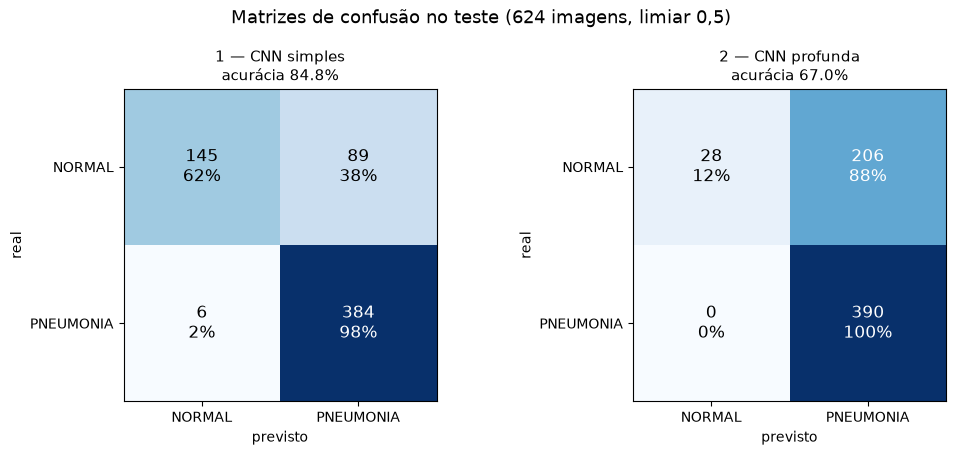

In [17]:
fig, eixos = plt.subplots(1, len(redes), figsize=(5.2 * len(redes), 4.6))

for eixo, nome in zip(np.atleast_1d(eixos), redes):
    previsoes = (probabilidades_teste[nome] >= 0.5).astype(np.float32)
    matriz = confusion_matrix(rotulos_teste, previsoes)

    eixo.imshow(matriz, cmap="Blues")
    for i in range(2):
        for j in range(2):
            proporcao = matriz[i, j] / matriz[i].sum()
            eixo.text(j, i, f"{matriz[i, j]}\n{proporcao:.0%}", ha="center", va="center",
                      fontsize=12,
                      color="white" if matriz[i, j] > matriz.max() / 2 else "black")

    eixo.set_xticks([0, 1], CLASSES)
    eixo.set_yticks([0, 1], CLASSES)
    eixo.set_xlabel("previsto")
    eixo.set_ylabel("real")
    eixo.set_title(f"{nome}\nacurácia {comparativo.loc[nome, 'acurácia']:.1%}", fontsize=11)

fig.suptitle("Matrizes de confusão no teste (624 imagens, limiar 0,5)", fontsize=13)
fig.tight_layout()
plt.show()

### Qual dos dois escolher — decidido na validação, não no teste

A tabela acima é o **relatório** do experimento, não o critério de decisão. Escolher o vencedor
olhando a coluna de teste seria usar o teste para tomar uma decisão, e a partir daí o número dele
deixaria de ser uma estimativa honesta de desempenho em imagens novas — seria o melhor de duas
tentativas, que é sempre otimista.

Por isso a escolha do modelo é feita **na validação**, exatamente como a escolha do limiar mais
adiante. O teste só confirma depois.

In [18]:
probabilidades_val = {nome: probabilidades_de(redes[nome], pixels_val, rotulos_val)
                      for nome in MODELOS}

balanceada_val = {}
for nome, proba in probabilidades_val.items():
    previsto = (proba >= 0.5).astype(np.float32)
    vn, fp, fn, vp = confusion_matrix(rotulos_val, previsto).ravel()
    balanceada_val[nome] = (vp / (vp + fn) + vn / (vn + fp)) / 2

melhor = max(balanceada_val, key=balanceada_val.get)

print("acurácia balanceada na VALIDAÇÃO (critério de escolha):")
for nome, valor in balanceada_val.items():
    print(f"  {nome}: {valor:.4f}")
print(f"\nmodelo escolhido: {melhor}")
print(f"acurácia balanceada dele no teste: "
      f"{comparativo.loc[melhor, 'acurácia balanceada']:.4f}\n")

probabilidades_melhor = probabilidades_teste[melhor]
previsoes_melhor = (probabilidades_melhor >= 0.5).astype(np.float32)

print(classification_report(rotulos_teste, previsoes_melhor,
                            target_names=["NORMAL (0)", "PNEUMONIA (1)"], digits=3))

acurácia balanceada na VALIDAÇÃO (critério de escolha):
  1 — CNN simples: 0.9574
  2 — CNN profunda: 0.8537

modelo escolhido: 1 — CNN simples
acurácia balanceada dele no teste: 0.8021

               precision    recall  f1-score   support

   NORMAL (0)      0.960     0.620     0.753       234
PNEUMONIA (1)      0.812     0.985     0.890       390

     accuracy                          0.848       624
    macro avg      0.886     0.802     0.822       624
 weighted avg      0.867     0.848     0.839       624



A diagonal principal são os acertos. O quadrante que conta a história é o **superior direito**:
normais classificados como pneumonia. Era ele que dominava o erro da MLP artesanal — 139 dos
234 normais, 59% dos saudáveis mandados para exame desnecessário.

**Onde a rede erra.** Os erros mais graves não são os de probabilidade perto de 0,5 (dúvida
honesta), e sim os **confiantes** — probabilidade longe do corte e ainda assim errada. São eles
que a figura abaixo mostra.

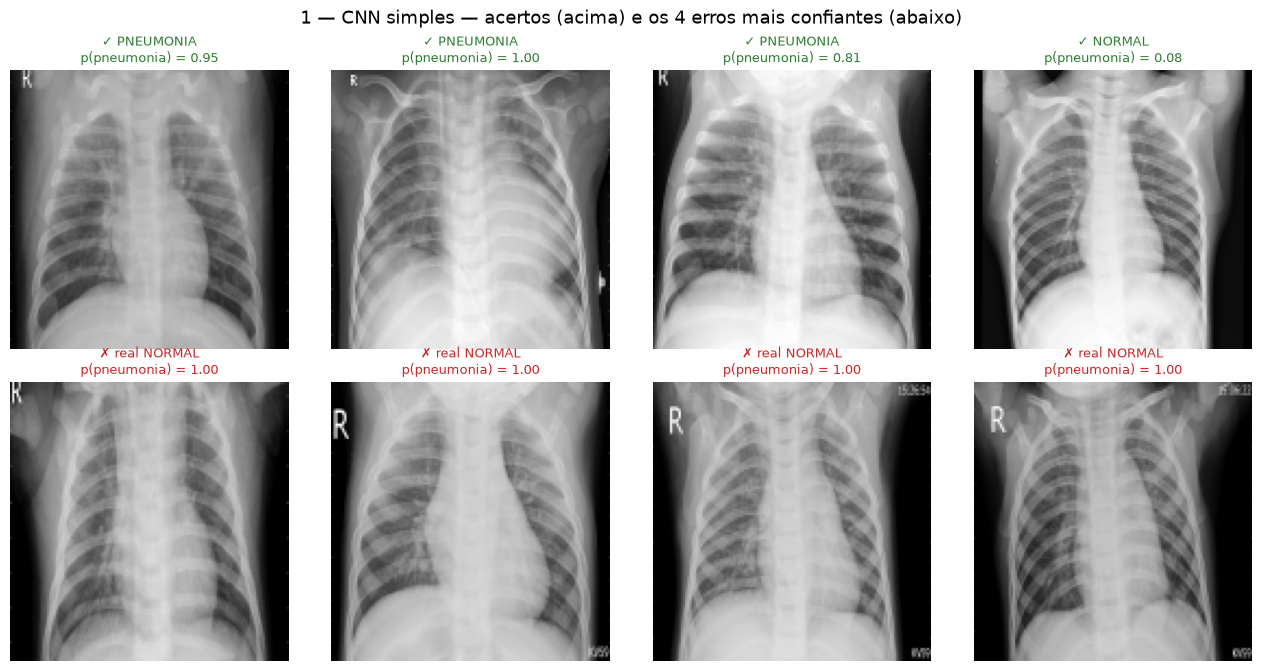

In [19]:
erros = np.flatnonzero(previsoes_melhor != rotulos_teste)
acertos = np.flatnonzero(previsoes_melhor == rotulos_teste)

confianca_erro = np.abs(probabilidades_melhor[erros] - 0.5)
erros_confiantes = erros[np.argsort(-confianca_erro)][:4]
acertos_amostra = random.Random(SEMENTE).sample(list(acertos), 4)

fig, eixos = plt.subplots(2, 4, figsize=(13, 6.8))

for coluna, indice in enumerate(acertos_amostra):
    eixo = eixos[0, coluna]
    eixo.imshow(pixels_teste[indice], cmap="gray")
    eixo.set_title(f"✓ {CLASSES[int(rotulos_teste[indice])]}\n"
                   f"p(pneumonia) = {probabilidades_melhor[indice]:.2f}",
                   fontsize=9, color="#2E7D32")
    eixo.axis("off")

for coluna, indice in enumerate(erros_confiantes):
    eixo = eixos[1, coluna]
    eixo.imshow(pixels_teste[indice], cmap="gray")
    eixo.set_title(f"✗ real {CLASSES[int(rotulos_teste[indice])]}\n"
                   f"p(pneumonia) = {probabilidades_melhor[indice]:.2f}",
                   fontsize=9, color="#C62828")
    eixo.axis("off")

fig.suptitle(f"{melhor} — acertos (acima) e os 4 erros mais confiantes (abaixo)", fontsize=13)
fig.tight_layout()
plt.show()

### Ajuste do limiar

*O que é:* a rede devolve uma probabilidade; 0,5 é só o corte padrão. Mover o corte troca um
tipo de erro pelo outro **sem retreinar nada**.

*Por que foi escolhido fazer isso:* 0,5 é o corte ótimo apenas quando as classes são
equilibradas e os dois erros custam o mesmo — nenhuma das duas coisas vale aqui. Com 74% de
pneumonia no treino, a rede aprende um viés a priori que empurra as probabilidades para cima;
no `test/`, menos desbalanceado, esse viés vira falso positivo. O limiar é o botão que corrige
isso a custo zero.

*Como impacta o modelo:* os pesos não mudam — muda apenas a operação de decisão. É o ajuste com
melhor relação custo/benefício disponível neste ponto.

**Mas o limiar precisa ser escolhido na validação.** Escolhê-lo olhando o teste e reportar o
ganho no mesmo teste é a mesma família de erro do vazamento de dados: o número sai otimista por
construção. O critério é a **acurácia balanceada** — média dos dois recalls, que pesa NORMAL e
PNEUMONIA igualmente, ao contrário da acurácia simples, que num conjunto 74/26 se deixa comprar
por acertar a classe frequente.

In [20]:
def recalls_em(rotulos, probabilidades, limiar):
    previsto = (probabilidades >= limiar).astype(np.float32)
    (vn, fp), (fn, vp) = confusion_matrix(rotulos, previsto)
    return vn / (vn + fp), vp / (vp + fn), (vn + vp) / len(rotulos)


GRADE = np.linspace(0.05, 0.95, 91)
proba_val_melhor = probabilidades_val[melhor]      # reaproveita o que já foi calculado acima

# Escolha do corte: so a validacao participa desta linha.
balanceadas_val = [np.mean(recalls_em(rotulos_val, proba_val_melhor, t)[:2])
                   for t in GRADE]
limiar_escolhido = float(GRADE[int(np.argmax(balanceadas_val))])

print(f"limiar escolhido na validação: {limiar_escolhido:.2f} "
      f"(acurácia balanceada {max(balanceadas_val):.4f} na validação)\n")

comparacao_limiar = pd.DataFrame([
    dict(zip(["recall NORMAL", "recall PNEUMONIA", "acurácia"],
             recalls_em(rotulos_teste, probabilidades_melhor, t)),
         limiar=f"{t:.2f}{rotulo}")
    for t, rotulo in [(0.5, " (padrão)"), (limiar_escolhido, " (validação)")]
]).set_index("limiar").round(4)

comparacao_limiar["acurácia balanceada"] = (
    comparacao_limiar[["recall NORMAL", "recall PNEUMONIA"]].mean(axis=1).round(4))
comparacao_limiar

limiar escolhido na validação: 0.24 (acurácia balanceada 0.9625 na validação)



,recall NORMAL,recall PNEUMONIA,acurácia,acurácia balanceada
limiar,,,,
0.50 (padrão),0.6197,0.9846,0.8478,0.8022
0.24 (validação),0.4359,0.9949,0.7853,0.7154


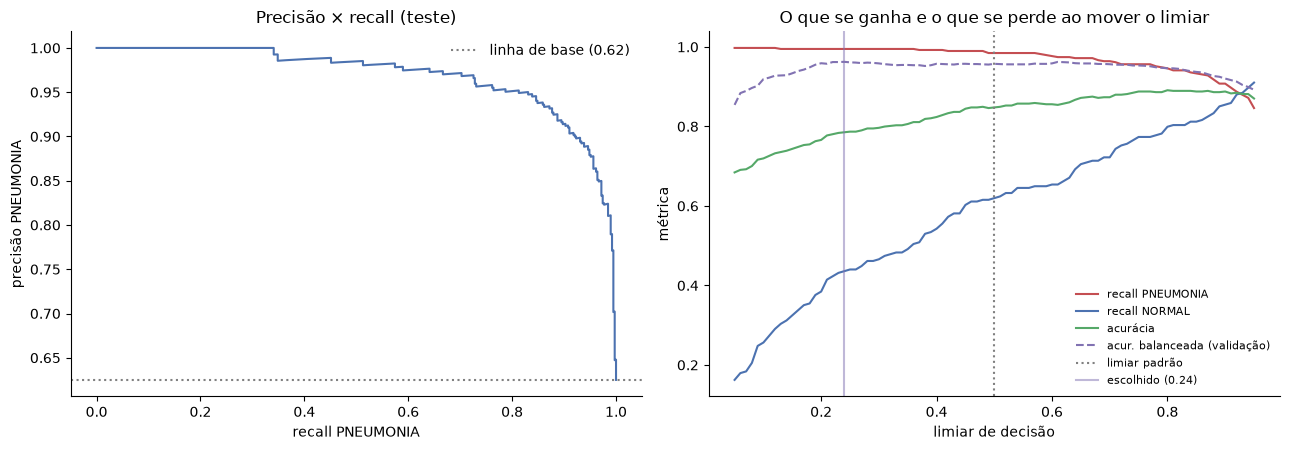

In [21]:
precisao, recall, _ = precision_recall_curve(rotulos_teste, probabilidades_melhor)

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))

eixos[0].plot(recall, precisao, color="#4C72B0")
eixos[0].axhline(float(rotulos_teste.mean()), ls=":", color="gray",
                 label=f"linha de base ({rotulos_teste.mean():.2f})")
eixos[0].set(xlabel="recall PNEUMONIA", ylabel="precisão PNEUMONIA",
             title="Precisão × recall (teste)")
eixos[0].legend(frameon=False)

curvas_teste = np.array([recalls_em(rotulos_teste, probabilidades_melhor, t)
                         for t in GRADE])

eixos[1].plot(GRADE, curvas_teste[:, 1], label="recall PNEUMONIA", color="#C44E52")
eixos[1].plot(GRADE, curvas_teste[:, 0], label="recall NORMAL", color="#4C72B0")
eixos[1].plot(GRADE, curvas_teste[:, 2], label="acurácia", color="#55A868")
eixos[1].plot(GRADE, balanceadas_val, ls="--", color="#8172B2",
              label="acur. balanceada (validação)")
eixos[1].axvline(0.5, ls=":", color="gray", label="limiar padrão")
eixos[1].axvline(limiar_escolhido, ls="-", color="#8172B2", alpha=0.5,
                 label=f"escolhido ({limiar_escolhido:.2f})")
eixos[1].set(xlabel="limiar de decisão", ylabel="métrica",
             title="O que se ganha e o que se perde ao mover o limiar")
eixos[1].legend(frameon=False, fontsize=8)

for eixo in eixos:
    eixo.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

A linha tracejada roxa é a única curva do painel da direita medida na **validação** — é ela que
decidiu o corte. As três cheias são o teste, e servem para ver o que o corte comprou. Onde as
curvas vermelha e azul se cruzam está o ponto de equilíbrio entre os dois erros; o limiar
padrão de 0,5 fica à esquerda dele, que é o lado de mandar saudável para exame.

**E aqui o ajuste saiu caro.** Na validação, 0,24 era claramente melhor que 0,5 (acurácia
balanceada 0,9625 contra 0,9574). No teste, o mesmo corte *piorou*: 0,7853 contra 0,8021 —
1,7 ponto perdido. O recall de PNEUMONIA subiu para 0,9949, mas o de NORMAL caiu de 0,6197
para 0,4359.

*Por que isso aconteceu, e por que não se conserta trocando o limiar de volta.* A validação foi
recortada de `train/`, então ela mede o desempenho em imagens **do mesmo lote de aquisição** do
treino. O `test/` é outro lote, e as probabilidades saem sistematicamente mais altas nele: na
validação o modelo *sub*-prevê PNEUMONIA no limiar 0,5 (por isso o ótimo está à esquerda, em
0,24), enquanto no teste ele já *sobre*-prevê (recall PNEUMONIA 0,9846 no limiar 0,5). Os dois
modelos deslocam para o mesmo lado — o modelo 2 chega a recall PNEUMONIA de 1,0000 —, o que
indica que o deslocamento é uma propriedade **dos dados**, não de uma arquitetura específica.

Olhar as curvas cheias e voltar para 0,5 seria escolher o limiar no teste, exatamente o
vazamento que a seção 6 acabou de remover, um nível acima. O procedimento aqui está certo e
custou 1,7 ponto; a correção de verdade não é mudar o corte, é ter uma validação que se pareça
com o cenário de uso — imagens de outro aparelho, outro hospital, outro período. Enquanto a
validação vier de dentro de `train/`, ela vai continuar dando conselhos ligeiramente errados
sobre o limiar.

## 7. Conclusões

**O experimento contradisse a hipótese da seção 4 — e esse é o resultado mais útil do notebook.**

O modelo 2 foi desenhado com todos os argumentos certos: mais profundidade, `BatchNorm`, dropout
progressivo, e capacidade deslocada da camada densa para as convoluções (424 mil parâmetros
convolucionais contra 66 mil do modelo 1). No papel, é a rede melhor construída. Na prática, no
`test/`, ela perdeu de longe.

| | modelo 1 — simples | modelo 2 — profunda | linha de base |
|---|---|---|---|
| parâmetros | 1.072.001 | 949.857 | — |
| acurácia balanceada na **validação** (critério de escolha) | **0,9574** | 0,8537 | — |
| acurácia no teste | **0,8478** | 0,6699 | 0,6250 |
| recall NORMAL no teste | **0,6197** | 0,1197 | 0,0000 |
| recall PNEUMONIA no teste | 0,9846 | 1,0000 | 1,0000 |
| acurácia balanceada no teste | **0,8021** | 0,5598 | 0,5000 |
| AUC no teste | 0,9517 | 0,9418 | 0,5000 |

**A validação escolheu certo.** O modelo 1 já vencia na validação (0,9574 contra 0,8537), e o
teste confirmou. Vale reparar no que isso significa: o procedimento honesto da seção 6 — decidir
na validação, conferir no teste — funcionou. Se a escolha tivesse sido feita na tabela de teste,
o resultado seria o mesmo, mas o número reportado não valeria nada como estimativa.

**O modelo 2 não aprendeu mal — ele decide mal.** O AUC dele é 0,9418, contra 0,9517 do modelo 1:
ordenando as imagens por probabilidade, as duas redes separam NORMAL de PNEUMONIA quase
igualmente bem. Toda a diferença de 24 pontos em acurácia balanceada está em *onde cai o corte*,
não no que a rede enxerga. No limiar 0,5 o modelo 2 responde PNEUMONIA para praticamente tudo
(recall PNEUMONIA exatamente 1,0000, recall NORMAL 0,1197) e a perda dele no teste é 1,3138
contra 0,4050 do modelo 1 — erra pouco em ordem, mas erra com muita confiança.

**Duas causas, uma medida e uma hipótese.**

1. *Medida: overfitting sem parada.* A partir da época 6 o modelo 2 continuou melhorando no treino
   (acurácia final 0,9683, contra 0,9413 do modelo 1) enquanto a perda de validação subia — de
   cerca de 0,11 na época 6 para 0,1749 na época 12 —, e a acurácia de validação caía de 0,9656
   para 0,9245. O `ReduceLROnPlateau` não viu nada disso porque está olhando **acurácia**, não
   perda, e `treina` devolve os pesos da **última** época, não os da melhor. Ou seja: os números
   da tabela acima provavelmente subestimam o modelo 2.
2. *Hipótese: sensibilidade ao deslocamento de distribuição.* Como a seção do limiar mostrou, as
   probabilidades saem sistematicamente mais altas no `test/` do que na validação, nas **duas**
   arquiteturas — logo o deslocamento é dos dados, não da rede. O modelo 2 apenas reage muito
   mais a ele. Uma explicação plausível é o `BatchNorm`: em `eval()` ele normaliza usando médias e
   variâncias acumuladas no treino, então, se o `test/` tem brilho e contraste diferentes, o
   deslocamento se propaga por cinco blocos em vez de nenhum. Isso é uma hipótese, não um
   diagnóstico — o teste seria recalcular as estatísticas de `BatchNorm` sobre o `test/`
   (*adaptação de domínio*) e ver se o recall de NORMAL sobe.

**Contra a MLP da fase anterior** (77% de acurácia, recall de NORMAL 0,41), a comparação tem que
ser feita modelo a modelo, e ela não é uniforme:

- O **modelo 1** ganha nas duas pontas: 0,8478 contra 0,77 de acurácia, e 0,6197 contra 0,41 de
  recall de NORMAL. Sobe em acurácia sem comprar isso com falso negativo, que é o ganho que
  justifica trocar pixels achatados por convolução.
- O **modelo 2** perde nas duas pontas: 0,6699 e 0,1197. Uma rede convolucional mais profunda,
  treinada sem cuidado com o ponto de parada, pode ficar *pior* que uma MLP simples.

**Qual usar.** O modelo 1, tal como está. Ele é o vencedor legítimo do procedimento e o único dos
dois que bate a linha de base de 0,6250 por uma margem que importa (0,8478). O modelo 2 não deve
ser descartado — deve ser retreinado com parada antecipada antes de ser julgado.

**Próximos passos, em ordem do que os dados já justificam:**

1. **Parada antecipada e checkpoint da melhor época.** É o único item que os números acima já
   provam ser necessário. Guardar os pesos da época de melhor acurácia balanceada de validação e
   monitorar a perda, não só a acurácia. Deixei de fora porque muda o procedimento de treino dos
   **dois** modelos e portanto invalida a comparação atual — é uma decisão sua, não minha.
2. **Validação que se pareça com o uso real.** Enquanto a validação sair de dentro de `train/`,
   ela vai continuar escolhendo limiares que não transferem (foi o que custou 1,7 ponto na seção
   6). Uma partição por paciente ou por aparelho resolveria mais do que qualquer mudança de
   arquitetura.
3. **`pos_weight` no `BCEWithLogitsLoss`.** O treino tem 74% de pneumonia; pesar a classe NORMAL
   ataca o recall baixo dela na própria função de custo, em vez de corrigir depois no limiar.
4. **Transferência de aprendizado.** Uma ResNet ou DenseNet pré-treinada parte de bordas e texturas
   já formadas; 5 mil imagens é pouco para aprender isso do zero, e é o caminho mais curto para
   passar dos 0,85.
5. **Ablação do pré-processamento.** CLAHE e aumento entraram juntos, então o ganho de cada um não
   está separado. Treinar o modelo 1 três vezes — sem nenhum dos dois, só com CLAHE, e com os
   dois — diria quanto cada etapa vale, em vez de creditar o resultado ao pacote inteiro.